# Fine-tuning: image → Wikipedia article (Russian)

Дообучаем `tuman/vit-rugpt2-image-captioning` (ViT encoder + ruGPT3large decoder) на задачу генерации структурированной wiki-статьи по фотографии.

**Архитектура:**
- `VisionEncoderDecoderModel` — encoder обрабатывает изображение → 197 patch-векторов по 768 dim → cross-attention в decoder
- Cross-attention уже обучен в базовой модели, мы лишь адаптируем его под наш формат
- LoRA на decoder (~1-3% параметров), encoder заморожен полностью

**Формат таргета:**
```
<title> Камышовый кот <lead> Камышовый кот — хищное млекопитающее... <section> Описание <paragraph> Камышовый кот крупнее домашних кошек...
```

In [1]:
!pip install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121


In [2]:
# Colab + Google Drive setup
# Загрузите папку с данными в: MyDrive/2task4/
# Структура должна быть:
#   MyDrive/2task4/data/metadata.jsonlx
#   MyDrive/2task4/data/images/...

from pathlib import Path


IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    DATA_ROOT = Path('/content/drive/MyDrive/2task4')
else:
    DATA_ROOT = Path('.')

print(f'DATA_ROOT: {DATA_ROOT.resolve()}')


DATA_ROOT: /Users/r-shangareev/PyProjects/2task4


In [3]:
import torch
torch.__version__

'2.11.0'

In [4]:
# Показать версии библиотек и сгенерировать pip install с фиксированными версиями
import importlib
import importlib.metadata as imd

libs = [
    ("torch", "torch"),
    ("torchvision", "torchvision"),
    ("torchaudio", "torchaudio"),
    ("transformers", "transformers"),
    ("peft", "peft"),
    ("accelerate", "accelerate"),
    ("PIL", "Pillow"),
    ("typing_extensions", "typing_extensions"),
    ("razdel", "razdel"),
    ("sacrebleu", "sacrebleu"),
    ("rouge_score", "rouge-score"),
]

versions = {}
print("Installed versions:")
for import_name, dist_name in libs:
    try:
        module = importlib.import_module(import_name)
        version = getattr(module, "__version__", None)
    except Exception:
        version = None
    if version is None:
        try:
            version = imd.version(dist_name)
        except Exception:
            version = "<not installed>"
    versions[dist_name] = version
    print(f"  {dist_name}: {version}")

# Генерация pip install команды с текущими версиями
pip_parts = []
for import_name, dist_name in libs:
    version = versions[dist_name]
    if version == "<not installed>":
        continue
    pip_parts.append(f"{dist_name}=={version}")

# Для torch/cu: если версия содержит +cu, добавляем индекс
torch_ver = versions.get("torch", "")
if "+cu" in str(torch_ver):
    idx = "https://download.pytorch.org/whl/" + torch_ver.split("+", 1)[1]
    print("\nPip install command:")
    print("pip install -U " + " ".join(pip_parts) + f" --index-url {idx}")
elif "+cpu" in str(torch_ver):
    print("\nPip install command:")
    print("pip install -U " + " ".join(pip_parts) + " --index-url https://download.pytorch.org/whl/cpu")
else:
    print("\nPip install command:")
    print("pip install -U " + " ".join(pip_parts))


Installed versions:
  torch: 2.11.0
  torchvision: 0.26.0
  torchaudio: 2.11.0
  transformers: 5.5.4
  peft: 0.19.0
  accelerate: 1.13.0
  Pillow: 11.3.0
  typing_extensions: 4.15.0
  razdel: 0.5.0
  sacrebleu: 2.6.0
  rouge-score: 0.1.2

Pip install command:
pip install -U torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 transformers==5.5.4 peft==0.19.0 accelerate==1.13.0 Pillow==11.3.0 typing_extensions==4.15.0 razdel==0.5.0 sacrebleu==2.6.0 rouge-score==0.1.2


In [5]:
import json
import re
import random
import os
from pathlib import Path
from pprint import pprint

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from razdel import sentenize

from transformers import (
    VisionEncoderDecoderModel,
    AutoImageProcessor,
    AutoTokenizer,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType

seed = 1337
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

DATA_ROOT = globals().get('DATA_ROOT', Path('.'))
DATA_FOLDER = DATA_ROOT / 'data'
CHECKPOINTS_DIR = DATA_ROOT / 'checkpoints'
CHECKPOINTS_DIR.mkdir(exist_ok=True)

# Храним кеш моделей в отдельной папке, чтобы контролировать размер
CACHE_DIR = DATA_ROOT / 'hf_cache'
CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault('HF_HOME', str(CACHE_DIR))
os.environ.setdefault('TRANSFORMERS_CACHE', str(CACHE_DIR))

Device: cpu


'hf_cache'

## 1. Загрузка данных и preprocessing

Главное отличие от `main.ipynb`: **не делаем `.lower()` и не убираем пунктуацию**.
Pretrained ruGPT обучался на нормальном тексте — наши таргеты должны ему соответствовать.

Разбиваем статью на части:
- `lead` = первые 3 предложения первого абзаца
- `sections` = остальные абзацы (не более 2), по 2 предложения каждый

In [6]:
arts = []
with open(DATA_FOLDER / 'metadata.jsonl', 'r') as f:
    for line in f:
        arts.append(json.loads(line))

print(f'Total articles: {len(arts)}')
print(f'Sample keys: {list(arts[0].keys())}')

Total articles: 4755
Sample keys: ['title', 'text', 'image_path', 'image_url', 'category']


In [7]:
def first_n_sentences(text: str, n: int) -> str:
    """Взять первые n предложений из текста через razdel."""
    sents = [s.text.strip() for s in sentenize(text) if s.text.strip()]
    return ' '.join(sents[:n])


def build_target(article: dict, max_sections: int = 10, sentences_per_section: int = 2) -> str:
    """
    Строит строку-таргет в формате со спецтокенами.

    Правило секций:
    - если строка/абзац содержит <= 3 слова, считаем это названием секции
    - иначе это обычный параграф без названия секции

    Пример выхода:
      <title> Камышовый кот <lead> Камышовый кот — хищное млекопитающее...
      <section> Награды <paragraph> В 2012 году получил премию...
      <paragraph> Дополнительный параграф без заголовка...
    """
    title = article['title'].strip()
    text = article['text'].strip()

    lines = [line.strip() for line in text.split('\n') if line.strip()]

    # Lead = первая строка/абзац с нормальной длиной
    lead_idx = None
    for i, line in enumerate(lines):
        if len(line.split()) > 3:
            lead_idx = i
            break
    if lead_idx is None:
        lead_idx = 0

    lead_text_raw = lines[lead_idx]
    lead = first_n_sentences(lead_text_raw, n=3)

    parts = [f'<title> {title}', f'<lead> {lead}']

    current_title = None
    sections_added = 0
    paragraphs_added = 0

    for line in lines[lead_idx + 1:]:
        if len(line.split()) <= 3:
            current_title = line.strip(':').strip()
            continue

        section_text = first_n_sentences(line, n=sentences_per_section)
        if not section_text:
            continue

        if current_title:
            if sections_added >= max_sections:
                continue
            parts.append(f'<section> {current_title}')
            parts.append(f'<paragraph> {section_text}')
            sections_added += 1
            current_title = None
        else:
            if paragraphs_added >= max_sections:
                continue
            parts.append(f'<paragraph> {section_text}')
            paragraphs_added += 1

    return ' '.join(parts)

In [8]:
texts = sorted(arts, key=lambda x: -len(x['text']))

In [9]:
from pprint import pprint

pprint(texts[1])

{'image_path': 'data/images/7b2ee2667704.png',
 'image_url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/b/bc/Nobelstiftung_logo.svg/960px-Nobelstiftung_logo.svg.png',
 'text': 'Фонд Нобеля (швед.  Nobelstiftelsen ) — частная организация в '
         'Стокгольме (Швеция), основанная 29 июня 1900 года для управления '
         'финансами и администрированием Нобелевских премий. Фонд основан на '
         'завещании Альфреда Нобеля, изобретателя динамита. Кроме задачи '
         'управления денежными средствами фонд Нобеля организует и проводит '
         'Нобелевские симпозиумы, на которых обсуждаются имеющие большое '
         'научное, социальное и культурное значение открытия.\n'
         '\n'
         'В своём завещании Альфред Нобель указал, чтобы его деньги были '
         'использованы для присуждения ежегодных премий по физике, химии, '
         'физиологии и медицине, литературе и миротворческой деятельности. '
         'Нобель завещал 94 % всего своего имущества (31 

In [10]:
pprint(build_target(texts[5]))

('<title> Список наводнений в Нидерландах <lead> В статье приведён '
 'хронологический список наводнений в Нидерландах. <paragraph> 838, 26 декабря '
 '— большая часть северо-запада страны затоплена во время шторма. Наводнение '
 'описывается епископом Пруденцием Труаским в Бертинских анналах, где '
 'сообщается о 2437 жертвах. <paragraph> 1014, 28 сентября — частично закрытое '
 'дюнами побережье страны впервые прорывается, Валхерен сильно пострадал. '
 'Кведлинбургские анналы сообщают о тысячах умерших. <paragraph> 1042, 2 '
 'ноября — наводнение, затронувшее, вероятно, только фламандское побережье, в '
 'частности устье реки Изер, упоминается в Annales Blandiniensis (Гент). '
 '<paragraph> 1163: несколько наводнений в Нидерландах, вызванных прорывом '
 'дамб вдоль русла Мааса, в результате которых устье Ауде-Рейна было полностью '
 'закрыто наносами. <paragraph> 1170 — первое наводнение Всех святых (1170) '
 '(Allerheiligenvloed). Затоплены обширные районы севера страны. <paragraph>

In [11]:
# Проверка на простой статье (только lead)
simple = arts[13]
print('Title:', simple['title'])
print('Raw text:', simple['text'][:300])
print()
print('Target:')
print(build_target(simple))

Title: Лесной кот
Raw text: Лесно́й кот, или лесна́я ко́шка, или ди́кая ко́шка, или ди́кий кот(лат. Felis silvestris от лат. fēles (fēlis) — «кошка», лат. silvestris — «лесной, находящийся, живущий или растущий в лесу, дикий, дикорастущий») — хищное млекопитающее из семейства кошачьих. В таксономии продолжаются споры, относятс

Target:
<title> Лесной кот <lead> Лесно́й кот, или лесна́я ко́шка, или ди́кая ко́шка, или ди́кий кот(лат. Felis silvestris от лат. fēles (fēlis) — «кошка», лат. silvestris — «лесной, находящийся, живущий или растущий в лесу, дикий, дикорастущий») — хищное млекопитающее из семейства кошачьих. В таксономии продолжаются споры, относятся ли европейские, азиатские и африканские дикие кошки к разным видам или подвидам. Согласно таксономической классификации, принятой в 2017 году, существует 2 вида: лат. Felis silvestris («европейский дикий кот», обитает в Европе, на Кавказе и в Турции) и лат. Felis lybica («африканский дикий (степной) кот», обитает в странах Африки, Б

In [12]:
# Проверка на статье с несколькими абзацами
multi = next(a for a in arts if len(a['text'].split('\n')) > 2)
print('Title:', multi['title'])
print()
print('Target:')
print(build_target(multi))

Title: Felis chaus kutas

Target:
<title> Felis chaus kutas <lead> Felis chaus kutas  (лат.) — подвид камышового кота класса млекопитающих отряда хищных семейства кошачьих. <paragraph> Обитает на водно-болотных угодьях в районах с засушливым климатом. Кот питается грызунами из рода пластинчатозубые крысы (Nesokia), песчанками индийская песчанка татера (Tatera indica), а также видами рыб из Инда. <paragraph> В последнее время места обитания кошки расширились за счет увеличения орошаемых сельскохозяйственных земель в Южной Азии. Встречается в основном в Пакистане (в регионе Фейсалабад) и в некоторых районах Индии.


In [13]:
train_arts, val_test_arts = train_test_split(arts, test_size=200, random_state=seed)
val_arts, test_arts = train_test_split(val_test_arts, test_size=0.5, random_state=seed)

print(f'Train: {len(train_arts)}, Val: {len(val_arts)}, Test: {len(test_arts)}')

Train: 4555, Val: 100, Test: 100


## 2. Загрузка модели и добавление спецтокенов

`tuman/vit-rugpt2-image-captioning` — `VisionEncoderDecoderModel` с уже обученным cross-attention.
Добавляем 4 спецтокена: они получат случайные embeddings, которые обучатся при fine-tuning.

После `add_special_tokens` обязательно вызвать `resize_token_embeddings` — иначе новые токены
не попадут в embedding матрицу и будут маппиться на старые id.

In [14]:
MODEL_NAME = 'tuman/vit-rugpt2-image-captioning'

model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME, cache_dir=CACHE_DIR)
feature_extractor = AutoImageProcessor.from_pretrained(MODEL_NAME, cache_dir=CACHE_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=CACHE_DIR)

# GPT2-based tokenizer не имеет pad_token — используем eos как pad
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

model.config.decoder_start_token_id = tokenizer.bos_token_id

print(f'Vocab size before: {len(tokenizer)}')
print(f'Decoder start token: {tokenizer.bos_token!r} (id={tokenizer.bos_token_id})')

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: tuman/vit-rugpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...23}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...23}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...23}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...23}.crossattention.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vocab size before: 50258
Decoder start token: '<s>' (id=1)


In [15]:
SPECIAL_TOKENS = ['<title>', '<lead>', '<section>', '<paragraph>']

num_added = tokenizer.add_special_tokens({'additional_special_tokens': SPECIAL_TOKENS})
print(f'Added {num_added} special tokens')
print(f'Vocab size after: {len(tokenizer)}')

# Расширяем embedding матрицу decoder под новый vocab
model.decoder.resize_token_embeddings(len(tokenizer))

# Проверка: каждый спецтокен должен кодироваться ровно в 1 токен
for tok in SPECIAL_TOKENS:
    ids = tokenizer.encode(tok, add_special_tokens=False)
    print(f'  {tok!r} -> ids={ids}, len={len(ids)}')
    assert len(ids) == 1, f'{tok} кодируется в {len(ids)} токенов вместо 1!'

Added 4 special tokens
Vocab size after: 50262


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


  '<title>' -> ids=[50258], len=1
  '<lead>' -> ids=[50259], len=1
  '<section>' -> ids=[50260], len=1
  '<paragraph>' -> ids=[50261], len=1


Tokenizing targets: 100%|██████████| 4755/4755 [00:01<00:00, 3679.06it/s]


Token length stats:
  min=17, max=821
  mean=102.0, median=79.0
  p90/p95/p99: [192.  252.  403.3]
  >512 tokens: 0.2%


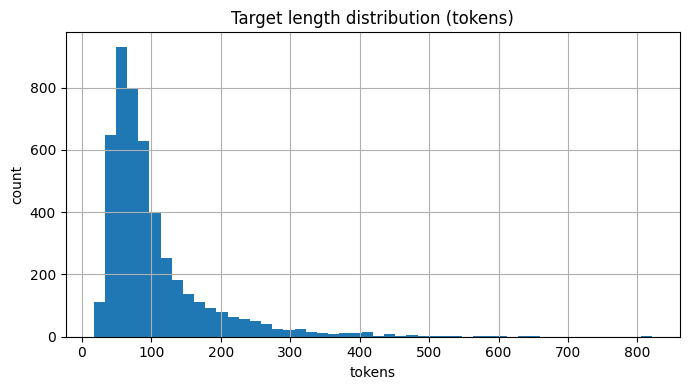

In [16]:
# Распределение длин таргета в токенах
# (считаем на текущем build_target + tokenizer)
lengths = []
for art in tqdm(arts, desc='Tokenizing targets'):
    target = build_target(art)
    ids = tokenizer(target, add_special_tokens=False).input_ids
    lengths.append(len(ids))

lengths = np.array(lengths)
print('Token length stats:')
print(f'  min={lengths.min()}, max={lengths.max()}')
print(f'  mean={lengths.mean():.1f}, median={np.median(lengths):.1f}')
print('  p90/p95/p99:', np.percentile(lengths, [90, 95, 99]))

CHECK_LEN = 512
print(f'  >{CHECK_LEN} tokens: {(lengths > CHECK_LEN).mean() * 100:.1f}%')

plt.figure(figsize=(7, 4))
plt.hist(lengths, bins=50)
plt.title('Target length distribution (tokens)')
plt.xlabel('tokens')
plt.ylabel('count')
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. LoRA

LoRA добавляет малоранговые матрицы `B·A` (rank × dim) к attention-весам.
Оригинальные веса заморожены, обновляется только `ΔW = α/r · B·A`.

В GPT2 attention реализован через один слой `c_attn` (объединённый QKV-проектор) —
именно его и оборачиваем. Encoder заморозим полностью: он и так хорошо извлекает признаки.

In [28]:
# Замораживаем encoder полностью
for param in model.encoder.parameters():
    param.requires_grad = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=['c_attn'],   # QKV-проектор в GPT2
    modules_to_save=['wte', 'lm_head'], # Обучаем эмбеддинги и выходной слой
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
    ensure_weight_tying=True,
)

# Оборачиваем только decoder, а не всю VisionEncoderDecoderModel
model.decoder = get_peft_model(model.decoder, lora_config)

# Замораживаем старые токены, чтобы обучались только новые
old_vocab_size = 50258

def freeze_old_embeddings_hook(grad):
    grad_clone = grad.clone()
    grad_clone[:old_vocab_size, :] = 0
    return grad_clone

# Регистрируем хуки на градиенты эмбеддингов и lm_head
model.decoder.get_input_embeddings().weight.register_hook(freeze_old_embeddings_hook)
if hasattr(model.decoder, 'get_output_embeddings') and model.decoder.get_output_embeddings() is not None:
    model.decoder.get_output_embeddings().weight.register_hook(freeze_old_embeddings_hook)

model.decoder.print_trainable_parameters()

trainable params: 158,533,632 || all params: 1,145,554,944 || trainable%: 13.8390


/Users/r-shangareev/PyProjects/env/lib/python3.11/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/Users/r-shangareev/PyProjects/env/lib/python3.11/site-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [29]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)')

Trainable: 159,714,816 / 1,233,125,376 (12.95%)


## 4. Dataset

**`__getitem__` возвращает:**
- `pixel_values`: `[3, 224, 224]` — обработанное `feature_extractor`-ом изображение
- `labels`: `[MAX_TARGET_LEN]` — токены таргета, где padding заменён на `-100`

Почему `-100`: `CrossEntropyLoss` по умолчанию игнорирует `ignore_index=-100`,
поэтому модель не штрафуется за предсказание паддингов.

In [30]:
# 256 было выбрано для экономии VRAM.
# Можно увеличить до 512 (или 768), но тогда снизить batch_size при OOM.
# Лимит GPT2-контекста у ruGPT3large — 1024 токена.
MAX_TARGET_LEN = 512


class WikiFinetuneDataset(torch.utils.data.Dataset):

    def __init__(self, articles: list[dict], feature_extractor, tokenizer):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.tokenizer = tokenizer
        self.samples = []
        skipped = 0

        # Важно: НЕ держим все изображения в памяти.
        # Храним только пути и текст; изображение читается в __getitem__.
        for article in articles:
            img_path = Path(article['image_path'])
            if not img_path.is_absolute():
                img_path = DATA_ROOT / img_path

            if not img_path.exists():
                skipped += 1
                continue

            target_text = build_target(article)
            self.samples.append((img_path, target_text))

        if skipped:
            print(f'Skipped {skipped} articles (missing images)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, target_text = self.samples[idx]

        # Открываем изображение только здесь — экономим RAM и ускоряем сборку датасета
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            img = img.copy()

        # feature_extractor: resize 224×224, нормализация под ViT
        pixel_values = self.feature_extractor(
            images=img,
            return_tensors='pt',
        ).pixel_values.squeeze(0)  # [3, 224, 224]

        encoding = self.tokenizer(
            target_text,
            max_length=MAX_TARGET_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        labels = encoding.input_ids.squeeze(0).clone()  # [MAX_TARGET_LEN]

        # PAD → -100: CrossEntropyLoss игнорирует эти позиции
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {'pixel_values': pixel_values, 'labels': labels}

In [31]:
train_dataset = WikiFinetuneDataset(train_arts, feature_extractor, tokenizer)

In [32]:

val_dataset   = WikiFinetuneDataset(val_arts,   feature_extractor, tokenizer)
test_dataset  = WikiFinetuneDataset(test_arts,  feature_extractor, tokenizer)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

# Проверка одного элемента
sample_item = train_dataset[0]
print(f'pixel_values shape: {sample_item["pixel_values"].shape}')
print(f'labels shape:       {sample_item["labels"].shape}')
    
# Декодируем labels обратно для проверки (-100 → pad_id)
label_ids = sample_item['labels'].clone()
label_ids[label_ids == -100] = tokenizer.pad_token_id
print(f'Target preview: {tokenizer.decode(label_ids, skip_special_tokens=False)[:200]}')

Train: 4555, Val: 100, Test: 100
pixel_values shape: torch.Size([3, 224, 224])
labels shape:       torch.Size([512])
Target preview: <title> Треппинг <lead> Треппинг — применяемый на допечатной стадии полиграфического процесса (при изготовлении макета) приём маскировки дефектов приводки. Заключается в утолщении контуров плашек на о


In [38]:
BATCH_SIZE = 2 # на T4 можно попробовать 8
NUM_WORKERS = 2

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == 'cuda'),
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == 'cuda'),
)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train batches: 2278, Val batches: 50


In [39]:
print(1)

1


## 5. Тренировочный цикл

**Как считается лосс в `VisionEncoderDecoderModel`:**
1. `pixel_values` → encoder → `encoder_hidden_states` (197 × 768)
2. Decoder принимает `labels` (сдвинутые внутри модели) и cross-attention-ит к encoder output
3. `outputs.loss` = `CrossEntropy(logits, labels)`, `-100` игнорируются автоматически
4. Никаких ручных `reshape` — модель делает всё сама

In [40]:
def train_step(model, batch, optimizer, scheduler):
    model.train()

    pixel_values = batch['pixel_values'].to(DEVICE)
    labels       = batch['labels'].to(DEVICE)

    outputs = model(pixel_values=pixel_values, labels=labels)
    loss = outputs.loss

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    return loss.item()


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        pixel_values = batch['pixel_values'].to(DEVICE)
        labels       = batch['labels'].to(DEVICE)
        outputs = model(pixel_values=pixel_values, labels=labels)
        total_loss += outputs.loss.item()
        n_batches  += 1

    return total_loss / n_batches if n_batches > 0 else float('inf')

In [41]:
NUM_EPOCHS   = 15
LR           = 3e-4
WARMUP_RATIO = 0.05

model = model.to(DEVICE)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=0.01,
)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f'Total steps: {total_steps:,}, warmup steps: {warmup_steps}')

Total steps: 34,170, warmup steps: 1708


In [42]:
history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')

# Настройки сохранения для ограниченного диска
SAVE_ONLY_ADAPTER = True       # True = сохраняем только LoRA-адаптер (минимальный размер)
SAVE_EVERY_EPOCH = False       # True = сохранять после каждой эпохи (перезаписывая)
SAVE_EVERY_N_STEPS = 200       # None/0 = отключено, иначе чекпоинт каждые N батчей
ADAPTER_DIR = CHECKPOINTS_DIR / 'adapter_best'
ADAPTER_DIR.mkdir(exist_ok=True)

global_step = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # --- Train ---
    model.train()
    epoch_loss = 0.0
    n_batches  = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [train]', leave=False)
    for batch in pbar:
        loss = train_step(model, batch, optimizer, scheduler)
        epoch_loss += loss
        n_batches  += 1
        pbar.set_postfix({'loss': f'{loss:.4f}'})

        global_step += 1
        if SAVE_EVERY_N_STEPS and global_step % SAVE_EVERY_N_STEPS == 0:
            model.decoder.save_pretrained(ADAPTER_DIR)
            tokenizer.save_pretrained(ADAPTER_DIR)
            if not SAVE_ONLY_ADAPTER:
                model.encoder.save_pretrained(CHECKPOINTS_DIR / 'encoder')
                model.config.save_pretrained(CHECKPOINTS_DIR)
            print(f'  → Step checkpoint saved (step={global_step})')

    train_loss = epoch_loss / n_batches
    history['train_loss'].append(train_loss)

    # --- Validation ---
    val_loss = eval_epoch(model, val_loader)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')

    # --- Checkpoint ---
    save_reason = None
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_reason = 'best'
    elif SAVE_EVERY_EPOCH:
        save_reason = 'epoch'

    if save_reason:
        # Сохраняем только LoRA-адаптер (перезаписывает папку, не раздувает диск)
        model.decoder.save_pretrained(ADAPTER_DIR)
        tokenizer.save_pretrained(ADAPTER_DIR)

        if not SAVE_ONLY_ADAPTER:
            model.encoder.save_pretrained(CHECKPOINTS_DIR / 'encoder')
            model.config.save_pretrained(CHECKPOINTS_DIR)

        print(f'  → Checkpoint saved ({save_reason}, val_loss={val_loss:.4f})')

print('Training complete.')

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['train_loss'], label='train loss')
ax.plot(history['val_loss'],   label='val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training history')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## 6. Inference

**Как работает `model.generate()`:**
1. Encoder обрабатывает изображение → `encoder_hidden_states`
2. Decoder стартует с `bos_token_id` и авторегрессивно предсказывает токены
3. На каждом шаге cross-attention смотрит на `encoder_hidden_states`
4. Beam search (4 луча) выбирает наиболее вероятные последовательности

`skip_special_tokens=False` — оставляем `<section>` и другие маркеры для парсинга.

In [ ]:
@torch.no_grad()
def generate_article_raw(
    image: Image.Image,
    model,
    tokenizer,
    feature_extractor,
    num_beams: int = 4,
) -> str:
    """Генерирует сырую строку со спецтокенами по изображению."""
    model.eval()

    pixel_values = feature_extractor(
        images=image,
        return_tensors='pt',
    ).pixel_values.to(DEVICE)

    output_ids = model.generate(
        pixel_values=pixel_values,
        num_beams=num_beams,
        max_new_tokens=MAX_TARGET_LEN,
        no_repeat_ngram_size=3,
        length_penalty=1.2,
        early_stopping=True,
    )

    return tokenizer.decode(output_ids[0], skip_special_tokens=False)


def parse_article(raw_text: str) -> dict:
    """
    Парсит строку со спецтокенами в структурированный словарь.

    Вход:  '<title> Кот <lead> Кот — ... <section> Описание <paragraph> Кот большой...'
    Выход: {'title': 'Кот', 'lead': 'Кот — ...', 'sections': [{'title': 'Описание', 'text': '...'}]}
    """
    result = {'title': '', 'lead': '', 'sections': []}

    def extract_between(text, start_tok, end_toks):
        if start_tok not in text:
            return '', text
        after = text.split(start_tok, 1)[1].strip()
        for end in end_toks:
            if end in after:
                value, rest = after.split(end, 1)
                return value.strip(), end + rest
        return after.strip(), ''

    remaining = raw_text.strip()
    result['title'], remaining = extract_between(remaining, '<title>',     ['<lead>', '<section>'])
    result['lead'],  remaining = extract_between(remaining, '<lead>',      ['<section>'])

    while '<section>' in remaining:
        sec_title, remaining = extract_between(remaining, '<section>',    ['<paragraph>', '<section>'])
        sec_text,  remaining = extract_between(remaining, '<paragraph>',  ['<section>'])
        if sec_title or sec_text:
            result['sections'].append({'title': sec_title, 'text': sec_text})

    return result

In [ ]:
# Проверяем парсер на синтетическом примере
test_raw = ('<title> Камышовый кот <lead> Камышовый кот — хищное млекопитающее семейства кошачьих. '
            '<section> Описание <paragraph> Камышовый кот крупнее домашних кошек. '
            '<section> Распространение <paragraph> Распространён от Египта до Индокитая.')
pprint(parse_article(test_raw))

In [ ]:
# Генерация на тестовом примере
test_img_path, test_target = test_dataset.samples[0]
with Image.open(test_img_path) as img:
    test_img = img.convert('RGB')

raw_output = generate_article_raw(test_img, model, tokenizer, feature_extractor)
print('Raw output:')
print(raw_output)
print()
print('Parsed:')
pprint(parse_article(raw_output))
print()
print('Reference target:')
print(test_target)

## 7. Оценка на тестовой выборке

Считаем BLEU (char-level, подходит для русского) и ROUGE-L на `title + lead`.

In [ ]:
from sacrebleu.metrics import BLEU
from rouge_score import rouge_scorer as rs_module

bleu_metric  = BLEU(tokenize='char')
rouge_metric = rs_module.RougeScorer(['rougeL'], use_stemmer=False)


def evaluate_on_test(model, dataset, n_samples: int = 50):
    hypotheses  = []
    references  = []
    rouge_scores = []

    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))

    for idx in tqdm(indices, desc='Evaluating'):
        img_path, target_text = dataset.samples[idx]
        with Image.open(img_path) as img:
            img = img.convert('RGB')

        raw  = generate_article_raw(img, model, tokenizer, feature_extractor)
        hyp  = parse_article(raw)
        ref  = parse_article(target_text)

        hyp_text = (hyp['title'] + ' ' + hyp['lead']).strip()
        ref_text = (ref['title'] + ' ' + ref['lead']).strip()

        hypotheses.append(hyp_text)
        references.append(ref_text)
        rouge_scores.append(rouge_metric.score(ref_text, hyp_text)['rougeL'].fmeasure)

    bleu_score  = bleu_metric.corpus_score(hypotheses, [references])
    mean_rouge  = sum(rouge_scores) / len(rouge_scores)

    print(f'BLEU (char): {bleu_score.score:.2f}')
    print(f'ROUGE-L:     {mean_rouge:.4f}')
    return hypotheses, references


hyps, refs = evaluate_on_test(model, test_dataset, n_samples=50)

In [ ]:
# Ручной просмотр нескольких примеров
for i in range(3):
    print(f'--- Sample {i + 1} ---')
    print(f'Generated : {hyps[i][:200]}')
    print(f'Reference : {refs[i][:200]}')
    print()

## 8. Экспорт модели для деплоя

`merge_and_unload()` встраивает LoRA матрицы в базовые веса — получаем обычный GPT2
без зависимости от `peft`. Это важно для CPU-деплоя: нет лишних зависимостей, модель загружается быстрее.

In [ ]:
EXPORT_DIR = DATA_ROOT / 'model_export'
EXPORT_DIR.mkdir(exist_ok=True)

# Объединяем LoRA веса с базовыми и убираем PEFT обёртку
merged_decoder = model.decoder.merge_and_unload()

export_model = VisionEncoderDecoderModel(
    encoder=model.encoder,
    decoder=merged_decoder,
)
export_model.config = model.config

export_model.save_pretrained(EXPORT_DIR)
tokenizer.save_pretrained(EXPORT_DIR)
feature_extractor.save_pretrained(EXPORT_DIR)

print(f'Saved to {EXPORT_DIR}/')
print('Files:', [p.name for p in sorted(EXPORT_DIR.iterdir())])

In [ ]:
# Проверка: загружаем обратно и делаем тест-генерацию
loaded_model = VisionEncoderDecoderModel.from_pretrained(EXPORT_DIR)
loaded_tok   = AutoTokenizer.from_pretrained(EXPORT_DIR)
loaded_fe    = AutoImageProcessor.from_pretrained(EXPORT_DIR)

loaded_model.eval()
test_img_path, _ = test_dataset.samples[0]
with Image.open(test_img_path) as img:
    test_img = img.convert('RGB')
raw = generate_article_raw(test_img, loaded_model, loaded_tok, loaded_fe)
print('Test generation from exported model:')
print(raw[:400])

## 9. Инференс локальных чекпоинтов с LoRA

Загружаем базовую модель + адаптер из `adapter_best_embed` и делаем генерацию с картинкой.

In [51]:
import matplotlib.pyplot as plt
from peft import PeftModel

def test_inference_lora(adapter_dir, sample_idx=0):
    # Загружаем базовую модель
    base_model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
    
    # Загружаем токенизатор из адаптера (там новые токены)
    tok = AutoTokenizer.from_pretrained(adapter_dir)
    fe = AutoImageProcessor.from_pretrained(MODEL_NAME)
    
    # Ресайзим эмбеддинги базовой модели под новый словарь перед загрузкой LoRA
    base_model.decoder.resize_token_embeddings(len(tok))
    
    # Подгружаем LoRA адаптер и новые эмбеддинги
    base_model.decoder = PeftModel.from_pretrained(base_model.decoder, adapter_dir)
    base_model.eval()
    
    # Берем сэмпл
    img_path, target_text = test_dataset.samples[sample_idx]
    
    with Image.open(img_path) as img:
        test_img = img.convert('RGB')
        
        # Показываем картинку
        plt.figure(figsize=(5, 5))
        plt.imshow(test_img)
        plt.axis('off')
        plt.show()
        
    # Генерируем
    generated_raw = generate_article_raw(test_img, base_model, tok, fe)
    
    print("\n=== TARGET ===")
    print(target_text)
    print("\n=== GENERATED ===")
    print(generated_raw)

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: tuman/vit-rugpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...23}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...23}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...23}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...23}.crossattention.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


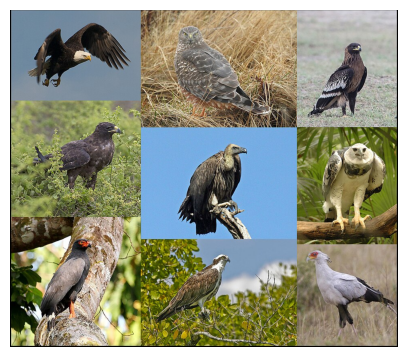

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== TARGET ===
<title> Ястребообразные <lead> Ястребообра́зные (лат. Accipitriformes) — отряд хищных птиц из подкласса новонёбных (Neognathae), объединяющий ястребов, коршунов, орлов и других птиц. В составе отряда выделяют 4 семейства: ястребиных (Accipitridae), скопиных (Pandionidae), птиц-секретарей (Sagittariidae) и американских грифов (Cathartidae). Скопиные и птицы-секретари являются монотипическими семействами и представлены одним родом каждый, американские грифы — пятью родами. <paragraph> Ранее ястребиные, скопиные, птицы-секретари и американские грифы объединялись вместе с соколиными (Falconidae) в один отряд, который назывался либо отрядом ястребообразных, либо соколообразных, либо отрядом дневных хищных птиц, и мог носить латинское название Accipitriformes либо Falconiformes. К настоящему времени, благодаря генетическим исследованиям отряд был разделён.

=== GENERATED ===
<s><title> Psittaciformes <lead> Pseudococcidae (лат.) — подсемейство птиц из семейства совиных. <para

In [53]:
test_inference_lora('adapted_best_embed2', sample_idx=23)